# 12 Object detection

In [104]:
import os
import json
import math
import random
import pathlib
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt

from IPython.core.magic import register_cell_magic

import tensorflow as tf

os.environ["KERAS_BACKEND"] = "jax"

import keras
import keras_hub

@register_cell_magic
def backend(line, cell):
    current, required = os.environ.get("KERAS_BACKEND", ""), line.split()[-1]
    if current == required:
        get_ipython().run_cell(cell)
    else:
        print(
            f"This cell requires the {required} backend. To run it, change KERAS_BACKEND to "
            f"\"{required}\" at the top of the notebook, restart the runtime, and rerun the notebook."
        )

Object detection is all about drawing bounding boxes around objects of interest in a picture. This enables you to know not just which objects are in a picture, but also where they are. Common applications:

- *Counting* — Find out how many instances of an object are in an image.
- *Tracking* — Track how objects move in a scene over time by performing object detection on every frame of a movie.
- *Cropping* — Identify the area of an image that contains an object of interest to crop it and send a higher-resolution version of the image patch to a classifier or an Optical Character Recognition (OCR) model.


<!-- ![Figure showing how object detectors draw boxes around objects in an image and label them.](images/chollet/figure12.1.png) -->

<img alt="Figure showing how object detectors draw boxes around objects in an image and label them." src="https://raw.githubusercontent.com/jchwenger/DLWP/refs/heads/main/lectures/06/images/chollet/figure12.1.png">

[DLWP](https://deeplearningwithpython.io/chapters/chapter12_object-detection/), Chapter 12, Figure 12.1

Couldn't we do this with segmentation? Yes, segmentation is a superset of detection, returning all the information a detection model does, and more. However, it's computationally more costly. A good detection model is much faster. Also, segmentation labelling is also more time-consuming to produce!

## Single-stage vs. two-stage object detectors

Two categories of detection architectures:

- *Two-stage detectors*: first extract region proposals and make predictions for each region (models: Region-based Convolutional Neural Networks (R-CNN));
- *Single-stage detectors*: make predictions on the whole image in one go (models: RetinaNet or the You Only Look Once (YOLO) family).


A two-stage model first produces partially overlapping bounding boxes, that are *region proposals* (for potential objects). Then a second model looks at each region proposal and classifies it into a number of classes. Regions with low scores across all classes are discarded. More steps are required to refine the bounding boxes and and eliminate duplicates.

<!-- ![Figure showing how an R-CNN first extracts region proposals and then classifies the proposals with a ConvNet (a CNN).](images/chollet/figure12.2.png) -->

<img alt="Figure showing how an R-CNN first extracts region proposals and then classifies the proposals with a ConvNet (a CNN)." src="https://raw.githubusercontent.com/jchwenger/DLWP/refs/heads/main/lectures/06/images/chollet/figure12.2.png">

[DLWP](https://deeplearningwithpython.io/chapters/chapter12_object-detection/), Chapter 12, Figure 12.2

At first, the first stage used so-called *heuristics*, i.e. hard-coded rules. And in the end, those systems were computationally fairly expensive.

Later on (around 2015), the usual story of Deep Learning happened: how about designing a single 'endo-to-end' system that would tackle the same task? This led to *single-stage detectors* (such as [RetinaNet](https://arxiv.org/abs/1708.02002), [Single Shot MultiBox Detectors (SSD)](https://arxiv.org/abs/1512.02325), and the [You Only Look Once](https://arxiv.org/abs/1506.02640) family, abbreviated as YOLO – pun intended). Recent models are now much faster and efficient than two-stage counterparts, and YOLO is the most popular detection model.

## Training a YOLO model from scratch

We will use the [COCO dataset](https://cocodataset.org/#home) ("Common Objects in Context"), is one of the best-known and most commonly used object detection datasets. It consists of real-world photos from a number of different sources plus human-created annotations (object labels, bounding box annotations, and full segmentation masks).

### Downloading the COCO dataset

Note: the dataset is ~18Gb zipped, it takes a while to download!

In [142]:
images_path = keras.utils.get_file(
    "coco",
    "http://images.cocodataset.org/zips/train2017.zip",
    extract=True,
)
annotations_path = keras.utils.get_file(
    "annotations",
    "http://images.cocodataset.org/annotations/annotations_trainval2017.zip",
    extract=True,
)

MODELS_DIR = pathlib.Path("models")

The above downloads all the images, and all the metadata: each image has an ID, and the metadata information is also associated with the same ID.

The bounding box information will be `x, y, width, height` **from the top left corner of the image**. We will normalize all those to give locations within a `[0, 1]` unit square.

In [29]:
with open(f"{annotations_path}/annotations/instances_train2017.json", "r") as f:
    annotations = json.load(f)

images = {image["id"]: image for image in annotations["images"]}

def scale_box(box, width, height):
    """
    Converts bounding box to coordinates on a unit square, given the `width` and
    `height` of the source image.
    """
    scale = 1.0 / max(width, height)
    x, y, w, h = [v * scale for v in box]
    # correct either x or y (one of the two dims will be adjusted to
    # make the image square, see `draw_image` below)
    x += (height - width) * scale / 2 if height > width else 0
    y += (width - height) * scale / 2 if width > height else 0
    return [x, y, w, h]

# Aggregates all bounding box annotations by image ID
metadata = {}
for annotation in annotations["annotations"]:
    img_id = annotation["image_id"]
    if img_id not in metadata:
        metadata[img_id] = {"boxes": [], "labels": []}
    image = images[img_id]
    box = scale_box(annotation["bbox"], image["width"], image["height"])
    metadata[img_id]["boxes"].append(box)
    metadata[img_id]["labels"].append(annotation["category_id"])
    metadata[img_id]["path"] = images_path + "/train2017/" + image["file_name"]
metadata = list(metadata.values())

#### Inspecting the dataset

In [30]:
len(metadata)

117266

In [31]:
min([len(x["boxes"]) for x in metadata])

1

In [32]:
max([len(x["boxes"]) for x in metadata])

93

In [33]:
max(max(x["labels"]) for x in metadata) + 1

91

In [34]:
n = 435
# n = np.random.randint(0, len(metadata))
metadata[n]

{'boxes': [[0.12471874999999999, 0.275, 0.57640625, 0.333703125],
  [0.0, 0.152078125, 0.7938125, 0.687640625],
  [0.0, 0.125140625, 1.0, 0.7498593750000001]],
 'labels': [17, 15, 2],
 'path': '/Users/jcw/.keras/datasets/coco/train2017/000000171809.jpg'}

Convert class label back into human-readable names using a `keras_hub` utility.

In [35]:
[keras_hub.utils.coco_id_to_name(x) for x in metadata[435]["labels"]]

['cat', 'bench', 'bicycle']

We have 117,266 images. Each image can have anywhere from 1 to 93 objects with an associated bounding box. There are only 91 possible labels for objects, chosen by the COCO dataset creators (find them [here](https://github.com/amikelive/coco-labels/blob/master/coco-labels-paper.txt)).

### Visualizing a COCO image with box annotation

[`matplotlib.patches.Rectangle` doc](https://matplotlib.org/stable/api/_as_gen/matplotlib.patches.Rectangle.html)

In [36]:
color_map = {0: "gray"}

def label_to_color(label):
    # Uses the golden ratio to generate new hues of a bright color with
    # the HSV colorspace    
    if label not in color_map:
        h, s, v = (len(color_map) * 0.618) % 1, 0.5, 0.9
        color_map[label] = mpl.colors.hsv_to_rgb((h, s, v))
    return color_map[label]

def draw_box(ax, box, text, color):
    x, y, w, h = box
    # ec: edgecolor, fc: facecolor (filling)
    ax.add_patch(mpl.patches.Rectangle((x, y), w, h, lw=1, ec=color, fc="none"))
    textbox = dict(fc=color, pad=1, ec="none")
    # va: vertical alignment; ha: horizontal alignment
    ax.text(x + w, y, text, c="white", size=8, va="top", ha="right", bbox=textbox)

def draw_image(ax, image):
    """
    Draws the image on a unit square with (0, 0) at the top left
    """
    # force the figure to be square, no ticks
    ax.set(xlim=(0, 1), ylim=(1, 0), xticks=[], yticks=[], aspect="equal")
    image = plt.imread(image)
    height, width = image.shape[:2]
    # Pads the image so it fits inside the unit square
    hpad = (1 - height / width) / 2 if width > height else 0
    wpad = (1 - width / height) / 2 if height > width else 0
    extent = [wpad, 1 - wpad, 1 - hpad, hpad]
    ax.imshow(image, extent=extent)

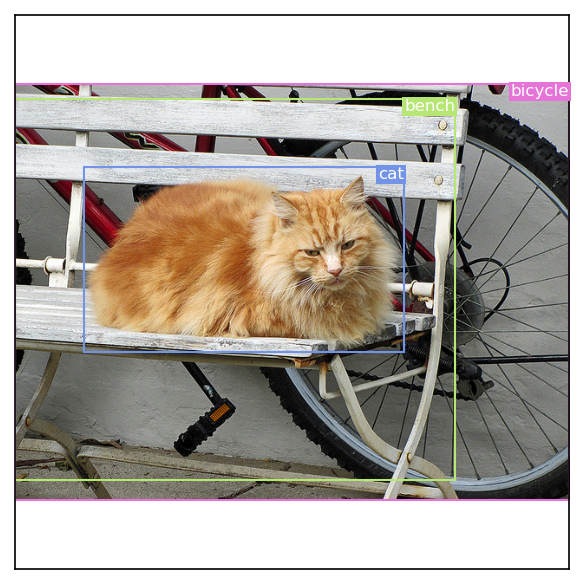

In [37]:
sample = metadata[435]
# create the plot
ig, ax = plt.subplots(dpi=150)
# draw the image
draw_image(ax, sample["path"])
# add the boxes & labels
for box, label in zip(sample["boxes"], sample["labels"]):
    label_name = keras_hub.utils.coco_id_to_name(label)
    draw_box(ax, box, label_name, label_to_color(label))
plt.show()

### Limiting the dataset size

The full dataset is 22GB unzipped! Best if we limit that, so that we have results faster. A good pipeline would be to start with experiments with the reduced dataset, and train with the full one later, when the parameter space has been well studied (and if there's access to the appropriate hardware, e.g. pay for Google Colab credits and use an H100).

Here, we limit our dataset to contain only images with four or less boxes, and we shuffle (originally it's ordered by object type).

In [38]:
metadata = list(filter(lambda x: len(x["boxes"]) <= 4, metadata))
random.shuffle(metadata)

### Creating a YOLO model

The YOLO model is a single stage detector: it will make its predictions in one go. It will divide an image up into a **grid** and predict **two separate outputs** at each grid location:
- a **bounding box** with a **confidence score** (to account for the fact that many grid locations have no object – high confidence if the object is there, low if not) and
- a **class label**.

In the [original paper](https://arxiv.org/abs/1506.02640), the model predicts multiple boxes per grid location... Also, they trained their ConvNet backbone from scratch on ImageNet, whereas we pull a pre-trained backbone from KerasHub. Finally, we use ResNet that uses **strided convolutions** (instead of max pooling), better when we care about the *spatial location* of what we are detecting, like in chapter 11.

<!-- ![YOLO outputs as visualized in the first YOLO paper](images/chollet/figure12.4.png) -->

<img alt="YOLO outputs as visualized in the first YOLO paper" src="https://raw.githubusercontent.com/jchwenger/DLWP/refs/heads/main/lectures/06/images/chollet/figure12.4.png">

[DLWP](https://deeplearningwithpython.io/chapters/chapter12_object-detection/#creating-a-yolo-model), Chapter 12, Figure 12.4

#### Model definition

In [18]:
IMAGE_SIZE = 448

backbone = keras_hub.models.Backbone.from_preset(
    "resnet_50_imagenet",
)
preprocessor = keras_hub.layers.ImageConverter.from_preset(
    "resnet_50_imagenet",
    image_size=(IMAGE_SIZE, IMAGE_SIZE),
)

For each slot in our grid, we will predict:
- five numbers for the bounding box & confidence
- the rest is the `class probability map`

In [19]:
GRID_SIZE = 6
NUM_LABELS = 91

inputs = keras.Input(shape=(IMAGE_SIZE, IMAGE_SIZE, 3))
x = backbone(inputs)

# Makes our backbone outputs smaller and then flattens the output features
x = keras.layers.Conv2D(512, (3, 3), strides=(2, 2))(x)
x = keras.layers.Flatten()(x)

# Passes our flattened feature maps through two densely connected layers
x = keras.layers.Dense(2048, activation="relu", kernel_initializer="glorot_normal")(x)
x = keras.layers.Dropout(0.5)(x)
x = keras.layers.Dense(GRID_SIZE * GRID_SIZE * (NUM_LABELS + 5))(x)

# Reshapes outputs to a 6 × 6 grid
x = keras.layers.Reshape((GRID_SIZE, GRID_SIZE, NUM_LABELS + 5))(x)

# Split box into (cx, cy, w, h) and class predictions
box_predictions = x[..., :5]
class_predictions = keras.layers.Activation("softmax")(x[..., 5:])

# Functional syntax: passing a dict to be able to retrieve the two outputs by key
outputs = {"box": box_predictions, "class": class_predictions}
model = keras.Model(inputs, outputs)

In [20]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 448, 448,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ res_net_backbone    │ (None, 14, 14,    │ 23,561,152 │ input_layer_1[0]… │
│ (ResNetBackbone)    │ 2048)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 6, 6, 512) │  9,437,696 │ res_net_backbone… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 18432)     │          0 │ conv2d[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 2048)      │ 37,750,784 │ flatten[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 2048)      │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 3456)      │  7,081,344 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape (Reshape)   │ (None, 6, 6, 96)  │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_1          │ (None, 6, 6, 91)  │          0 │ reshape[0][0]     │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item (GetItem)  │ (None, 6, 6, 5)   │          0 │ reshape[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 6, 6, 91)  │          0 │ get_item_1[0][0]  │
│ (Activation)        │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 77,830,976 (296.90 MB)

 Trainable params: 77,777,856 (296.70 MB)

 Non-trainable params: 53,120 (207.50 KB)

### Readying the COCO data for the YOLO model

Each grid detector will be responsible for detecting **any boxes whose center falls inside the grid box**.

Our model will output five floats for the box `(x, y, w, h, confidence)`:
- The `x` and `y` will represent the **object’s center relative to the bounds of the grid cell** (from 0 to 1).
- The `w` and `h` will represent the **object’s size relative to the image size**.

In [147]:
def to_grid(box):
    """
    Convert the normalised `x, y, w, h` to their grid-sized equivalent
    `(ix, iy)` will be ints, e.g. 2, 3
    `cx - ix, cy - iy are remainders within [0,1] boxes, e.g. (.23, .77)
    `w, h` remain untouched
    """
    x, y, w, h = box
    cx, cy = (x + w / 2) * GRID_SIZE, (y + h / 2) * GRID_SIZE
    ix, iy = int(cx), int(cy)
    return (ix, iy), (cx - ix, cy - iy, w, h)

def from_grid(loc, box):
    """
    Convert the grid-sized `x, y, w, h` to their normalized equivalent
    """    
    (xi, yi), (x, y, w, h) = loc, box
    x = (xi + x) / GRID_SIZE - w / 2
    y = (yi + y) / GRID_SIZE - h / 2
    return (x, y, w, h)

In [83]:
# creating arrays first, we'll fill them in below
class_array = np.zeros((len(metadata), GRID_SIZE, GRID_SIZE))
box_array = np.zeros((len(metadata), GRID_SIZE, GRID_SIZE, 5))

# filling in the class array
for index, sample in enumerate(metadata):
    boxes, labels = sample["boxes"], sample["labels"]
    for box, label in zip(boxes, labels):
        (x, y, w, h) = box
        # Finds all grid cells whose center falls inside the box        
        left, right = math.floor(x * GRID_SIZE), math.ceil((x + w) * GRID_SIZE)
        bottom, top = math.floor(y * GRID_SIZE), math.ceil((y + h) * GRID_SIZE)
        # for simplicity: no overlapping boxes! (last label overwrites previous ones)
        class_array[index, bottom:top, left:right] = label

# filling in the box array
for index, sample in enumerate(metadata):
    boxes, labels = sample["boxes"], sample["labels"]
    for box, label in zip(boxes, labels):
        # Transforms the box to the grid coordinate system: `(xi, yi)` gives the grid indices (ints)       
        (xi, yi), (grid_box) = to_grid(box)
        box_array[index, yi, xi] = [*grid_box, 1.0]
        # Makes sure the class label for the box's center location matches the box        
        class_array[index, yi, xi] = label

#### Checking our arrays

In [151]:
# See: https://chatgpt.com/share/699c41bb-fda8-8005-a3f0-4dbe89a271b9
n = 11

print("Classes ground truth for each grid cell:")
print(class_array[n])

# print(np.vectorize(keras_hub.utils.coco_id_to_name)(class_array[n]))
string_classes = np.apply_along_axis(
    lambda row: [f"{keras_hub.utils.coco_id_to_name(x):>21}" for x in row],
    axis=-1,
    arr=class_array[n],
)
print()
print("Translated into human-readable labels:")
print(string_classes)

np.set_printoptions(linewidth=300)
string_boxes = np.apply_along_axis(
    lambda row: ",".join(f"{x:.1f}" for x in row[:-1]) + f" ({row[-1]})",
    axis=-1,
    arr=box_array[n],
)
print()
print("Each box prediction as 'x,y,h,w (score)':")
print(string_boxes)

Classes ground truth for each grid cell:
[[ 0.  0.  0.  0.  0.  0.]
 [ 0.  0. 84. 84. 84. 84.]
 [ 0.  0. 84. 84. 84. 84.]
 [ 0. 84. 84. 16. 84. 84.]
 [ 0. 84. 84. 84. 84. 84.]
 [ 0. 84. 84. 84. 84. 84.]]

Translated into human-readable labels:
[['            unlabeled' '            unlabeled' '            unlabeled' '            unlabeled' '            unlabeled' '            unlabeled']
 ['            unlabeled' '            unlabeled' '                 book' '                 book' '                 book' '                 book']
 ['            unlabeled' '            unlabeled' '                 book' '                 book' '                 book' '                 book']
 ['            unlabeled' '                 book' '                 book' '                 bird' '                 book' '                 book']
 ['            unlabeled' '                 book' '                 book' '                 book' '                 book' '                 book']
 ['            unlabe

### Drawing predictions

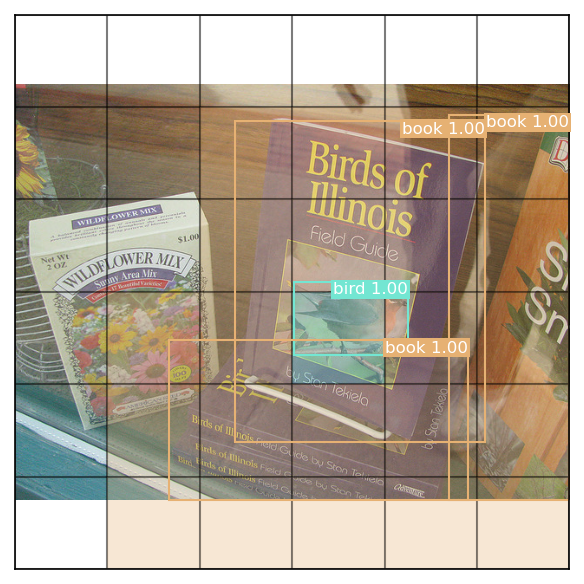

In [155]:
def draw_prediction(image, boxes, classes, cutoff=None):
    fig, ax = plt.subplots(dpi=150)
    draw_image(ax, image)
    # Draws the YOLO output grid and class probability map    
    for yi, row in enumerate(classes):
        for xi, label in enumerate(row):
            color = label_to_color(label) if label else "none"
            x, y, w, h = (v / GRID_SIZE for v in (xi, yi, 1.0, 1.0))
            r = mpl.patches.Rectangle((x, y), w, h, lw=1, ec="black", fc=color, alpha=0.3)
            ax.add_patch(r)
    # Draws all boxes at each grid location above our cutoff            
    for yi, row in enumerate(boxes):
        for xi, box in enumerate(row):
            box, confidence = box[:4], box[4]
            if not cutoff or confidence >= cutoff:
                box = from_grid((xi, yi), box)
                label = classes[yi, xi]
                color = label_to_color(label)
                name = keras_hub.utils.coco_id_to_name(label)
                draw_box(ax, box, f"{name} {max(confidence, 0):.2f}", color)
    plt.show()

draw_prediction(metadata[n]["path"], box_array[n], class_array[n], cutoff=1.0)

### Building our `tf.data.Dataset` object

For `tf.data.Dataset.from_tensor_slices`, see the [`tf.data.Dataset` tutorial](https://www.tensorflow.org/api_docs/python/tf/data/Dataset#source_datasets).

In [192]:
# Loads and resizes the model with tf.data
def load_image(path):
    x = tf.io.read_file(path)
    x = tf.image.decode_jpeg(x, channels=3)
    return preprocessor(x)

images_ds = tf.data.Dataset.from_tensor_slices([x["path"] for x in metadata])
images_ds = images_ds.map(load_image, num_parallel_calls=8)
labels_ds = {"box": box_array, "class": class_array}
labels_ds = tf.data.Dataset.from_tensor_slices(labels_ds)

BATCH_SIZE = 16
dataset = tf.data.Dataset.zip(images_ds, labels_ds).batch(BATCH_SIZE).prefetch(2)
# the first 500 will be our val dataset, the rest our train
val_dataset, train_dataset = dataset.take(500), dataset.skip(500)

#### Test

In [117]:
for img_batch, label_batch in val_dataset.take(1):
    print(img_batch.shape)
    print("boxes:", label_batch["box"].shape)
    # print(label_batch["box"][0])
    print("classes:", label_batch["class"].shape)
    print(label_batch["class"][0])

(16, 448, 448, 3)
boxes: (16, 6, 6, 5)
classes: (16, 6, 6)
tf.Tensor(
[[ 0.  0.  0.  0.  0.  0.]
 [ 0.  0.  0.  0.  0.  0.]
 [ 0. 16. 16. 16. 16.  0.]
 [ 0. 16. 16. 16. 16.  0.]
 [ 0. 16. 16. 16. 16.  0.]
 [ 0.  0.  0.  0.  0.  0.]], shape=(6, 6), dtype=float64)


### Training the YOLO model

#### Loss function

The last thing we need is the loss function. Our model outputs predicted boxes and predicted grid labels (we will have multiple losses for each output — Keras will simply sum the losses).

For the object class (classification loss), we can use `sparse_categorical_crossentropy` as before.

The box loss, however, is a bit more involved:
- first, the paper authors use the **sum-squared error of the difference between the target box parameters and the predicted ones**. We will only compute this error for grid cells with actual boxes in the labeled data.
- second, the trickiest part, is the box confidence output, as we want the confidence output to reflect not just the presence of an object, but also how good the predicted box is. For that, the authors use the **Intersection over Union (IoU) metric**. If a grid cell is empty, the predicted confidence at the location should be zero. However, if a grid cell contains an object, we can use the IoU score between the current box prediction and the actual box as the target confidence value.

See the [`chapter11_image-segmentation.ipynb`](https://github.com/jchwenger/DLWP/blob/main/lectures/06/chapter11_image-segmentation.ipynb) notebook for more on the IoU metric.


In [88]:
def unpack(box):
    """Unpacks a tensor of boxes
        from: [[center_x1,center_y1,w1,h1],[center_x2,center_y2,w2,h2],...]
        to:   [[center_x1,center_x2,...],[center_y1,center_y2,...],[w1,w2,...],[h1,h2,...]...]
    """
    return box[..., 0], box[..., 1], box[..., 2], box[..., 3]

def intersection(box1, box2):
    """
    Computes the intersection area between two box tensors (in a vectorized way)
    """
    cx1, cy1, w1, h1 = unpack(box1)
    cx2, cy2, w2, h2 = unpack(box2)
    # between the xs, select the left-most / right-most
    left = keras.ops.maximum(cx1 - w1 / 2, cx2 - w2 / 2)
    right = keras.ops.minimum(cx1 + w1 / 2, cx2 + w2 / 2)
    # between the ys, select the top-most / bottom-most
    bottom = keras.ops.maximum(cy1 - h1 / 2, cy2 - h2 / 2)
    top = keras.ops.minimum(cy1 + h1 / 2, cy2 + h2 / 2)
    # area of rectangle: multiply length of sides
    return keras.ops.maximum(0.0, right - left) * keras.ops.maximum(0.0, top - bottom)

def intersection_over_union(box1, box2):
    """
    Computes the IoU between two box tensors (in a vectorized way)
    """
    cx1, cy1, w1, h1 = unpack(box1)
    cx2, cy2, w2, h2 = unpack(box2)
    intersection_area = intersection(box1, box2)
    # area of rectangle: multiply length of sides
    area_box1 = keras.ops.maximum(w1, 0.0) * keras.ops.maximum(h1, 0.0)
    area_box2 = keras.ops.maximum(w2, 0.0) * keras.ops.maximum(h2, 0.0)
    union_area = area_box1 + area_box2 - intersection_area
    return keras.ops.divide_no_nan(intersection_area, union_area)

On top of that, the author papers add a few tricks:
  - scaling up the **box placement loss** by a factor of **five**, (boosting its importance).
  - Since most grid cells are empty, they scale down the **confidence loss in empty locations** by a factor of **two** (keeping the influence of zero confidence predictions under control).
  - They take the **square root of the width and height before computing the loss** (stopping large boxes from mattering too much compared to small boxes). (Hack: we preserve the sign of the input, since our model might predict negative widths and heights at the start of training.)

In [95]:
def signed_sqrt(x):
    return  keras.ops.sign(x) * keras.ops.sqrt(keras.ops.abs(x) + keras.config.epsilon())

# required to serialise the model
@keras.saving.register_keras_serializable()
def box_loss(true, pred):
    # Unpacks values: (x,y), (w,h), confidence
    xy_true, wh_true, conf_true = true[..., :2], true[..., 2:4], true[..., 4:]
    xy_pred, wh_pred, conf_pred = pred[..., :2], pred[..., 2:4], pred[..., 4:]
    # If confidence_true is 0.0, there is no object in this grid cell.    
    no_object = conf_true == 0.0
    # Computes box placement errors (signed_sqrt in case our model predicts negative wh)
    xy_error = keras.ops.square(xy_true - xy_pred)
    wh_error = keras.ops.square(signed_sqrt(wh_true) - signed_sqrt(wh_pred))
    # Computes confidence error    
    iou = intersection_over_union(true, pred)
    conf_target = keras.ops.where(no_object, 0.0, keras.ops.expand_dims(iou, -1))
    conf_error = keras.ops.square(conf_target - conf_pred)
    # Concatenates the errors with scaling hacks    
    error = keras.ops.concatenate(
        (
            keras.ops.where(no_object, 0.0, xy_error * 5.0),
            keras.ops.where(no_object, 0.0, wh_error * 5.0),
            keras.ops.where(no_object, conf_error * 0.5, conf_error),
        ),
        axis=-1,
    )
    # Returns one loss value per sample; Keras will sum over the batch.    
    return keras.ops.sum(error, axis=(1, 2, 3))

##### Testing `box_loss`

In [148]:
# the box preds are shaped (batch, grid_h, grid_w, 5), I artificially add dimensions to make them (1,1,1,5)
dummy_true = np.array([[[[.2, .3,.5,.6, 1.]]]]) # try change 1. with 0.
dummy_pred = np.array([[[[.21,.31,.52, .6,.7]]]]) 

print(f"{dummy_true = } {dummy_true.shape}")
print(f"{dummy_pred = } {dummy_pred.shape}")

# Unpacks values: (x,y), (w,h), confidence
xy_true, wh_true, conf_true = dummy_true[..., :2], dummy_true[..., 2:4], dummy_true[..., 4:]
xy_pred, wh_pred, conf_pred = dummy_pred[..., :2], dummy_pred[..., 2:4], dummy_pred[..., 4:]

# If confidence_true is 0.0, there is no object in this grid cell.    
no_object = conf_true == 0.0
print()
print("Any location without object?", no_object)

# Computes box placement errors, with signed sqrt trick 
xy_error = keras.ops.square(xy_true - xy_pred)
wh_error = keras.ops.square(signed_sqrt(wh_true) - signed_sqrt(wh_pred))
print()
print(f"{xy_error = }")
print(f"{wh_error = }")

# Computes confidence error    
iou = intersection_over_union(dummy_true, dummy_pred)
conf_target = keras.ops.where(no_object, 0.0, keras.ops.expand_dims(iou, -1))
print()
print(f"{iou = }")
print(f"{conf_target = }")

conf_error = keras.ops.square(conf_target - conf_pred)
# Concatenates the errors with scaling hacks: 5 x for xy/wh error, .5 for scores
# but **only** if there's an object detected (otherwise xy/wh are zero
error = keras.ops.concatenate(
    (
        keras.ops.where(no_object, 0.0, xy_error * 5.0),
        keras.ops.where(no_object, 0.0, wh_error * 5.0),
        keras.ops.where(no_object, conf_error * 0.5, conf_error),
    ),
    axis=-1,
)
print()
print(f"final error factors with tweaks before summing:")
print(f"{error = }")
print()
print(f"-> sum: { keras.ops.sum(error, axis=(1, 2, 3)) }") # ('summing over all dimensions except 0')

dummy_true = array([[[[0.2, 0.3, 0.5, 0.6, 1. ]]]]) (1, 1, 1, 5)
dummy_pred = array([[[[0.21, 0.31, 0.52, 0.6 , 0.7 ]]]]) (1, 1, 1, 5)

Any location without object? [[[[False]]]]

xy_error = Array([[[[0.0001, 0.0001]]]], dtype=float32)
wh_error = Array([[[[0.0001961, 0.       ]]]], dtype=float32)

iou = Array([[[0.9305995]]], dtype=float32)
conf_target = Array([[[[0.9305995]]]], dtype=float32)

final error factors with tweaks before summing:
error = Array([[[[0.0005    , 0.0005    , 0.00098048, 0.        , 0.05317614]]]], dtype=float32)

-> sum: [0.05515662]


### Baselines

#### Class labels

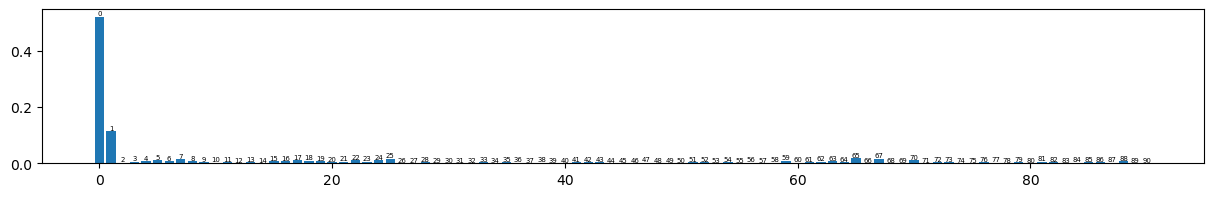

In [289]:
counts = np.bincount(class_array.astype(np.int64).ravel())
probs = counts / counts.sum()

fig = plt.figure(figsize=(15,2))
bars = plt.bar(range(len(probs)), probs)
for i, bar in enumerate(bars):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height(), str(i), ha='center', va='bottom', fontsize=5.)

In [182]:
keras_hub.utils.coco_id_to_name(0), keras_hub.utils.coco_id_to_name(1)

('unlabeled', 'person')

The 'unlabeled' class (0) is hugely over represented, followed by 'person' (1).

The entropy is, given a random variable $\mathcal {X} $:

$$\mathrm {H} (X):= -\sum _{ x\in {\mathcal {X} } } p(x) \log p(x) $$

This is the loss we would get if we used the best static (no context) predictor: always outputting the class probabilities present in our dataset (we would want a lower loss than that).

In [180]:
# a small epsilon for numeric stability
nll = - np.sum(probs * np.log(probs + 1e-12))
print(f"Baseline loss <> Entropy of the class labels: {nll.item()}.")

Baseline loss <> Entropy of the class labels: 2.416068186502584.


#### Boxes

In [190]:
x = tf.random.uniform((2,3))
y = tf.random.uniform((2,3))
tf.concat([x,y], axis=0).shape

TensorShape([4, 3])

##### Predict zero everywhere

In [281]:
losses = []
for _, batch_labels in val_dataset:
    y_true = batch_labels["box"].numpy()
    # first dummy loss, predict only zeros
    y_pred = np.zeros_like(y_true)
    loss = box_loss(y_true, y_pred)
    losses.append(loss)

zero_pred_loss = keras.ops.mean(losses).item()
print(f"Baseline dummy box loss: {zero_pred_loss}")

Baseline dummy box loss: 14.473191261291504


Not amazing, we can do better.

##### Predict the mean of our five values

In [253]:
# will accumulate [x,y,w,h,score]
xywhs_sum = np.zeros(5)
total_count = 0

for _, batch_labels in val_dataset:
    # (bs, g, g, 5)
    boxes = batch_labels["box"].numpy()
    # accumulate 5 features
    xywhs_sum += boxes.sum(axis=(0, 1, 2))
    # count elements: bs * g * g
    total_count += np.prod(boxes.shape[:3])

# divide by the total
xywhs_mean = xywhs_sum / total_count
print(xywhs_mean)

[0.02905818 0.02976274 0.02049936 0.01974102 0.06001042]


In [238]:
losses = []
for i, (_, batch_labels) in val_dataset.enumerate():
    loss = box_loss(batch_labels["box"].numpy(), xywhs_mean)
    losses.append(loss)
    # if i % 100 == 0:
    #     print(f"{i.numpy().item()}")

xywhs_mean_loss = keras.ops.mean(losses).item()
print(f"Baseline mean prediction loss: {xywhs_mean_loss}")

Baseline dummy box loss: 11.100520133972168


This number is high because a large number of grid cells are zero.

##### Predict the mean of our five values, using **only cells with a confidence score of 1.**

In [274]:
# will accumulate [x,y,w,h,score]
xywhs_score1_sum = np.zeros(5)
total_count = 0
count_score1 = 0

for _, batch_labels in val_dataset:
    boxes = batch_labels["box"].numpy()
    scores = boxes[..., 4]
    
    xywhs_score1_sum[..., 4] += scores.sum()
    # bs * g * g
    total_count += scores.size

    # mask to select xywh values only where confidence is 1
    mask = scores == 1.
    xywhs_score1_sum[..., :4] += boxes[..., :4][mask].sum(axis=0)
    # add the total number of True <> 1
    count_score1 += mask.sum()

xywhs_score1_mean = np.concatenate([
    # divide xywh only by the amount of cells with score of 1
    xywhs_score1_sum[...,:4] / count_score1,
    # divide the scores by the total number of cells
    xywhs_score1_sum[...,4:] / total_count
], axis = 0)

print(f"Found {count_score1:,} cells with score one, for a total of {total_count:,}.")
print(xywhs_score1_mean)

Found 17,283 cells with score one, for a total of 288,000.
[0.48421888 0.49595952 0.34159663 0.32895981 0.06001042]


In [276]:
losses = []
for i, (_, batch_labels) in val_dataset.enumerate():
    loss = box_loss(batch_labels["box"].numpy(), xywhs_score1_mean)
    losses.append(loss)

xywhs_score1_loss = keras.ops.mean(losses).item()
print(f"Baseline mean prediction loss: {xywhs_score1_loss}")

Baseline mean prediction loss: 3.249910831451416


#### Training

In [36]:
model.compile(
    optimizer=keras.optimizers.Adam(2e-4),
    loss={"box": box_loss, "class": "sparse_categorical_crossentropy"},
)
model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=4,
    callbacks=[
        keras.callbacks.ModelCheckpoint(
            MODELS_DIR / "resnet_50_coco.keras",
            save_best_only=True
        )
    ]    
)

Epoch 1/4
3201/3201 ━━━━━━━━━━━━━━━━━━━━ 1095s 317ms/step - box_loss: 4.7445 - class_loss: 2.5148 - loss: 7.2593 - val_box_loss: 2.1241 - val_class_loss: 1.8485 - val_loss: 3.9727
Epoch 2/4
3201/3201 ━━━━━━━━━━━━━━━━━━━━ 1005s 310ms/step - box_loss: 2.2321 - class_loss: 1.7362 - loss: 3.9683 - val_box_loss: 2.0005 - val_class_loss: 1.4747 - val_loss: 3.4752
Epoch 3/4
3201/3201 ━━━━━━━━━━━━━━━━━━━━ 1004s 310ms/step - box_loss: 1.9735 - class_loss: 1.4396 - loss: 3.4131 - val_box_loss: 1.9837 - val_class_loss: 1.2903 - val_loss: 3.2740
Epoch 4/4
3201/3201 ━━━━━━━━━━━━━━━━━━━━ 1005s 310ms/step - box_loss: 1.6964 - class_loss: 1.2480 - loss: 2.9443 - val_box_loss: 1.9817 - val_class_loss: 1.2071 - val_loss: 3.1888


### Reloading & testing our model

You can find the model I trained [here](https://drive.google.com/file/d/1oxbTmnEkl6LCi5k7K3Vk7NEVULf59Xkk/view?usp=sharing).

In [143]:
model_reloaded = keras.models.load_model(MODELS_DIR / "resnet_50_coco.keras")

In [157]:
# Rebatches our dataset to get a single sample instead of BATCH_SIZE
val_ds_iter = iter(val_dataset.rebatch(1))
metadata_iter = iter(metadata)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 229ms/step


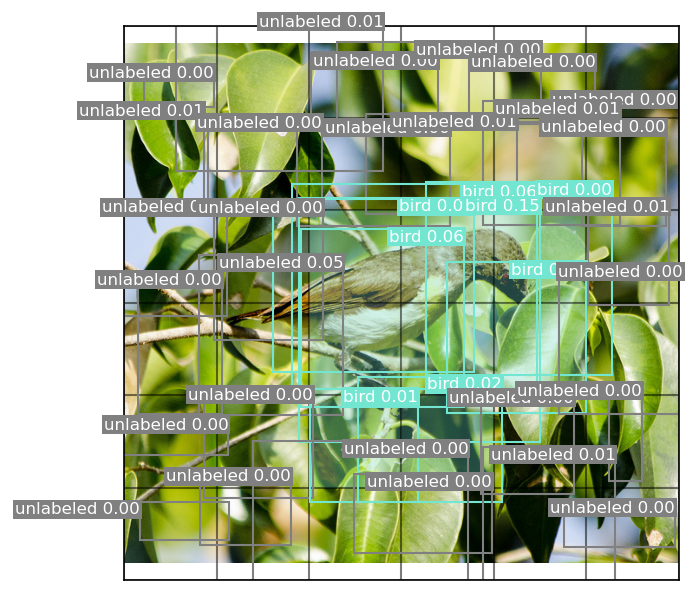

In [158]:
x, y = next(val_ds_iter)
preds = model_reloaded.predict(x)

boxes = preds["box"][0]
# Uses argmax to find the most likely label at each grid location
classes = np.argmax(preds["class"][0], axis=-1)
# Loads the image from disk to view it a full size
path = next(metadata_iter)["path"]

# without cut-off, you can see all the different boxes
draw_prediction(path, boxes, classes, cutoff=None)

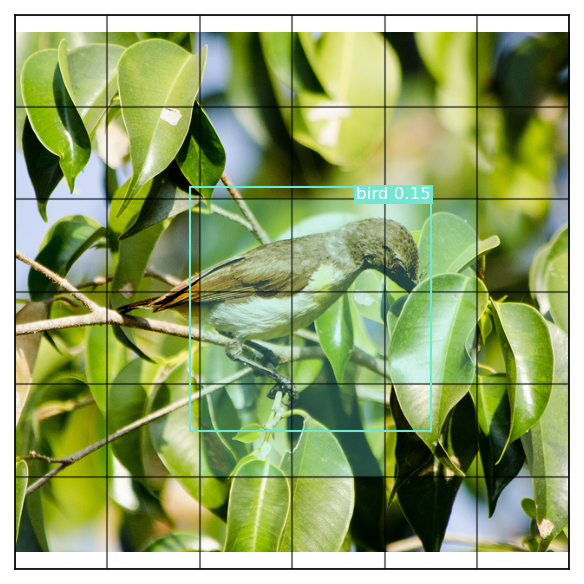

In [159]:
# with a manual cut-off
draw_prediction(path, boxes, classes, cutoff=.14)

A technique to select boxes beyond our hard-coded threshold is [**non-max suppression**](https://www.tensorflow.org/api_docs/python/tf/image/non_max_suppression).

To improve performance, we could:
- Train for more epochs
- Use the whole COCO dataset
- Use Data augmentation (e.g., translating and rotating input images and boxes) – tricky to implement!!
- Improve our class probability map for overlapping boxes
- Predict multiple boxes per grid location using a bigger output grid

### Save to Google Drive

In [ ]:
EXPORT = False

if EXPORT:
    # zip models
    !zip object-detection-coco.models.zip {MODELS_DIR}/*
    # connect to drive
    from google.colab import drive
    drive.mount('/content/drive')
    # copy zip to drive (adjust folder as needed)
    !cp object-detection-coco.models.zip drive/MyDrive/gold/IS53024B-Artificial-Intelligence/models

## Using a pretrained RetinaNet detector

Check out the steps [in the book](https://deeplearningwithpython.io/chapters/chapter12_object-detection/#using-a-pretrained-retinanet-detector)!

### See also

Keras tutorial on [RetinaNet](https://keras.io/examples/vision/retinanet/).  
Facebook Research's ["Detectron 2"](https://github.com/facebookresearch/detectron2) GitHub repository.